In [2]:
# ============================================================
# Data manipulation
# ============================================================
import pandas as pd
import numpy as np


# ============================================================
# Visualization
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

from functions.graph import graficar
from functions.style_graphs import EstiloBase


# ============================================================
# Statistical modeling
# ============================================================
import statsmodels.api as sm
import statsmodels.formula.api as smf


# ============================================================
# Statistical tests and diagnostics
# ============================================================
import scipy.stats as stats
from scipy.stats import t, shapiro

from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset
from statsmodels.stats.stattools import jarque_bera
from statsmodels.graphics.regressionplots import influence_plot
from statsmodels.nonparametric.smoothers_lowess import lowess

# ANCOVA Problem

In this section, we analyze a classical ANCOVA problem using cadmium exposure data.

Cadmium is a toxic element known to negatively affect respiratory function. In this study, researchers analyzed 84 men working in a cadmium-related industry. The goal is to understand how exposure impacts lung capacity while accounting for age differences.

The dataset includes the following variables:

- **vitcap**: Maximum volume of air a person can exhale after full inhalation (lung capacity).
- **age**: Age of the individual.
- **group**: Exposure category:
  - "high": more than 10 years of exposure
  - "low": less than 10 years of exposure
  - "no": no exposure



## Discussion

Before fitting any model, it is essential to understand the structure of the data.

A key concern in this type of analysis is whether groups are comparable. If groups differ systematically (e.g., in age distribution), direct comparisons may be misleading.

For example, initial inspection suggests that individuals in the "low" exposure group tend to be younger than those in the "high" exposure group. This imbalance can bias results if not properly addressed.

This is precisely where ANCOVA becomes useful: it allows us to adjust for continuous variables (such as age) when comparing groups.

## EDA

In [3]:
data = pd.read_table('data/cadmium.txt', sep=' ', decimal= ".")

data['group_category']=data['group'].apply(lambda x: 'high' if x == 1 else 'low' if x == 2 else 'no' ).astype('category')
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   group           84 non-null     int64   
 1   age             84 non-null     int64   
 2   vitcap          84 non-null     float64 
 3   group_category  84 non-null     category
dtypes: category(1), float64(1), int64(2)
memory usage: 2.3 KB


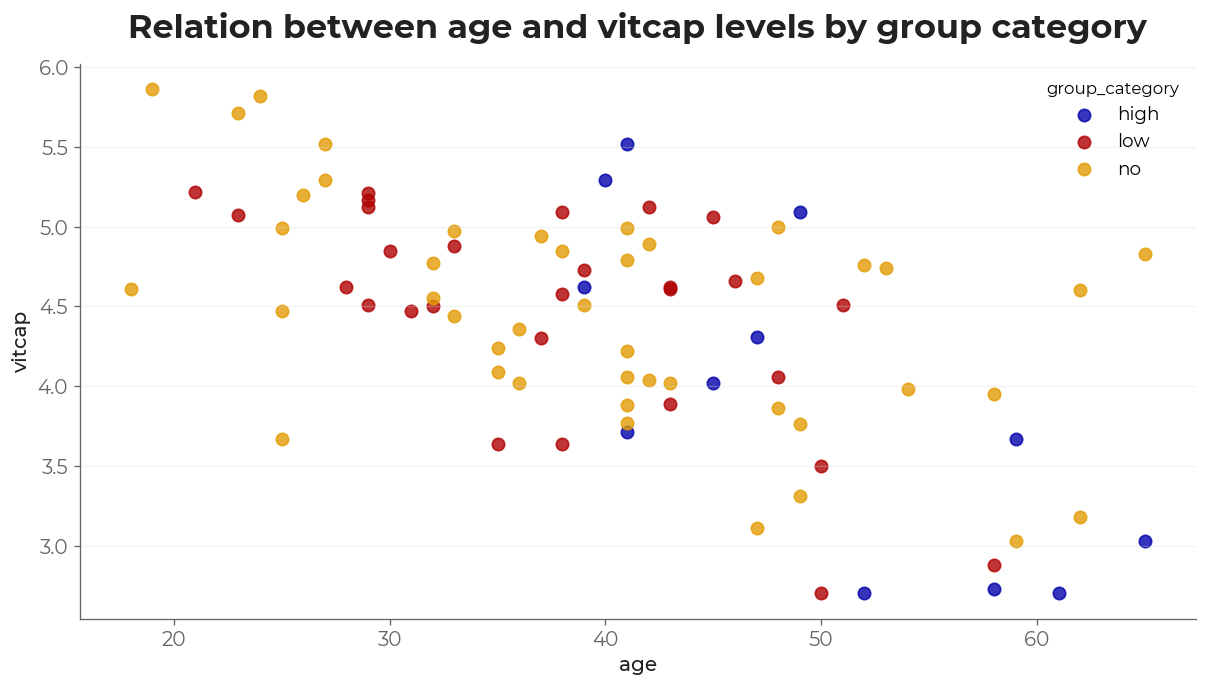

In [4]:


mi_estilo = EstiloBase(
    tipo_letra="Montserrat",
    grid_eje="y",
    fondo="white",
    paleta_colores=["#0402AB", "#AF0202", "#E39D06"],
    tam_titulo=20
)

fig, ax= graficar(
    tipo="scatter",
    df=data,
    x="age",
    y="vitcap",
    grupo="group_category",
    titulo="Relation between age and vitcap levels by group category",
    estilo=mi_estilo
)


From the scatter plot, we observe that there are no individuals younger than 40 years old in the "high" exposure group.

This lack of overlap is problematic, as it can lead to biased estimates when comparing groups. In particular, we would be extrapolating beyond the observed data for certain age ranges.

To address this issue, we restrict the analysis to individuals older than 38 years. While this reduces the sample size and discards some information, it improves comparability across groups and leads to more reliable conclusions.

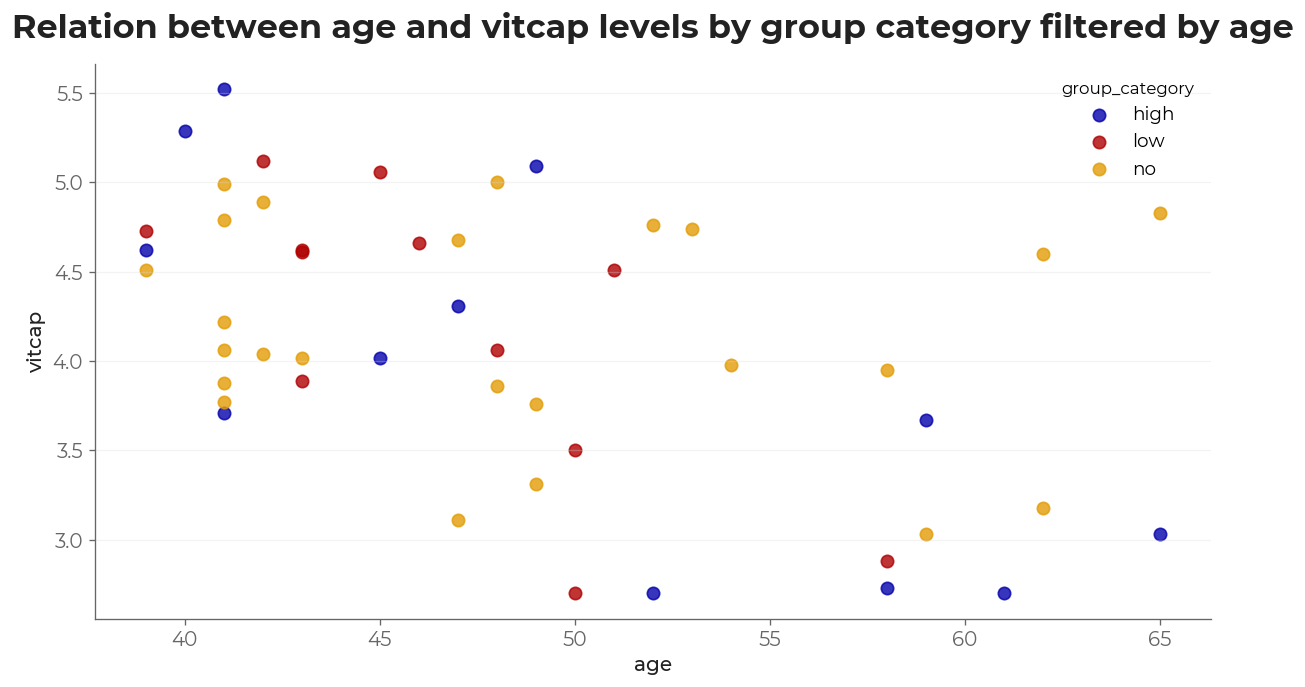

In [5]:
# Filter data those people older than 38 years old
data_f = data[data['age'] >= 39]
fig, _ =graficar(
    tipo="scatter",
    df=data_f,
    x="age",
    y="vitcap",
    grupo="group_category",
    titulo="Relation between age and vitcap levels by group category filtered by age",
    estilo=mi_estilo
)

## Model Specification

Our objective is to model lung capacity as a function of age and exposure group.

The ANCOVA model is defined as:

$$
E(y \mid group, age) = \beta_0 + \beta_1 low + \beta_2 no + \beta_3 age + \beta_4 (age \cdot low) + \beta_5 (age \cdot no)
$$

Here, the "high" group is used as the reference category.

To better understand the model, we can express it separately for each group:

- High exposure:
  $$
  E(y \mid group = high, age) = \beta_0 + \beta_3 \cdot age
  $$

- Low exposure:
  $$
  E(y \mid group = low, age) = (\beta_0 + \beta_1) + (\beta_3 + \beta_4) \cdot age
  $$

- No exposure:
  $$
  E(y \mid group = no, age) = (\beta_0 + \beta_2) + (\beta_3 + \beta_5) \cdot age
  $$

This formulation highlights that each group can have both different intercepts and different slopes.

In [6]:
# print the categories of the group_category variable, the first one is high, so its the reference category
data_f['group_category'].cat.categories

Index(['high', 'low', 'no'], dtype='object')

In [7]:
# Fit the model
model = smf.ols('vitcap ~ age * group_category', data=data_f).fit()

# Print the summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 vitcap   R-squared:                       0.394
Model:                            OLS   Adj. R-squared:                  0.321
Method:                 Least Squares   F-statistic:                     5.453
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           0.000592
Time:                        13:14:21   Log-Likelihood:                -43.205
No. Observations:                  48   AIC:                             98.41
Df Residuals:                      42   BIC:                             109.6
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

The first step is to evaluate whether the model provides a meaningful explanation of the response variable.

The overall F-test indicates that the model is statistically significant (p-value < 0.05), suggesting that at least one predictor contributes to explaining lung capacity.

Having established that the model is relevant, the next question is whether its structure can be simplified.

Recall that the model defines a separate regression line for each group:

$$
E(y \mid group = high, age) = \beta_0 + \beta_3 \cdot age
$$

$$
E(y \mid group = low, age) = (\beta_0 + \beta_1) + (\beta_3 + \beta_4) \cdot age
$$

$$
E(y \mid group = no, age) = (\beta_0 + \beta_2) + (\beta_3 + \beta_5) \cdot age
$$

From this formulation, we can see that differences between groups arise from two sources:
- shifts in the intercepts ($\beta_1$, $\beta_2$), and  
- differences in the slopes ($\beta_4$, $\beta_5$).

If we are able to show that $\beta_4 = 0$ and $\beta_5 = 0$, then all groups would share the same slope. In that case, the regression lines would be parallel.

This is an important simplification, as parallel lines imply that the effect of age is constant across groups, and group differences can be interpreted as fixed vertical shifts.

To formally assess this, we perform a general linear test:

$$
H_0: \beta_4 = 0 \ \text{and} \ \beta_5 = 0
\quad \text{vs} \quad
H_a: \beta_4 \neq 0 \ \text{or} \ \beta_5 \neq 0
$$

In [8]:
# Test specific hypotheses
# here I evaluate only b4 and b5, if both are equal to 0, then there is no interaction between age and group_category
K = np.array([
    [0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 1]
])

print(model.f_test(K))

<F test: F=5.266816953705993, p=0.009100154997444251, df_denom=42, df_num=2>


The F-test leads us to reject the null hypothesis ($p$-value = 0.0091 < 0.05), indicating that the slopes are not equal across all groups. Therefore, the regression lines are not parallel, and the full model must be retained.

However, this does not rule out the possibility that some pairs of groups may still share the same slope. To investigate this, we perform a set of simultaneous tests to compare slopes between pairs of groups.

Specifically, we consider the following hypotheses:

- $H_{01}: \beta_4 = 0 \quad \text{vs} \quad H_{a1}: \beta_4 \neq 0$

- $H_{02}: \beta_5 = 0 \quad \text{vs} \quad H_{a2}: \beta_5 \neq 0$

- $H_{03}: \beta_4 - \beta_5 = 0 \quad \text{vs} \quad H_{a3}: \beta_4 - \beta_5 \neq 0$

Each of these tests corresponds to comparing slopes between specific groups:

- If $\beta_4 = 0$, then the *high* and *low* groups share the same slope (i.e., their regression lines are parallel).

- If $\beta_5 = 0$, then the *high* and *no* groups share the same slope.

- If $\beta_4 - \beta_5 = 0$, then the *low* and *no* groups have equal slopes.

This approach allows us to identify whether partial simplifications of the model are possible, even if full parallelism across all groups is not supported.

In [9]:
# print the order of the coefficients in the model to ensure the correct mapping with the contrast matrix
print(model.model.exog_names)

['Intercept', 'group_category[T.low]', 'group_category[T.no]', 'age', 'age:group_category[T.low]', 'age:group_category[T.no]']


In [11]:
# desing matrix for simultaneous test
K = np.array([
    [0, 0, 0, 0, 1, 0],   # age:group[T.low] = 0
    [0, 0, 0, 0, 0, 1],   # age:group[T.no] = 0
    [0, 0, 0, 0, 1, -1]   # age:group[T.low] - age:group[T.no] = 0
], dtype=float)

m = np.array([0, 0, 0], dtype=float) 

# constrast expected values from the model
beta_hat = model.params.to_numpy()
# covariance matrix of the parameters
V_beta = model.cov_params().to_numpy()
# compute the estimates, standard errors, t-values, and p-values for the contrasts
#theta_hat
est = K @ beta_hat - m
# var(theta_hat)
V_lin = K @ V_beta @ K.T
# standard errors
se = np.sqrt(np.diag(V_lin))
# t-values
t_obs = est / se
# degrees of freedom
df_resid = int(round(model.df_resid))

# correlation matrix of the contrasts
Dinv = np.diag(1 / se)
R = Dinv @ V_lin @ Dinv
# make R symmetric
R = (R + R.T) / 2

print("Matriz de correlación de contrastes:")
print(R)

Matriz de correlación de contrastes:
[[ 1.          0.38718209  0.79230584]
 [ 0.38718209  1.         -0.2557698 ]
 [ 0.79230584 -0.2557698   1.        ]]


In [13]:
# functions for aproximation of p-values for simultaneous tests
def rmvt_singular(n_sim, df, corr, seed=123, tol=1e-12):
    rng = np.random.default_rng(seed)

    # make corr symmetric to avoid numerical issues
    corr = (corr + corr.T) / 2

    # spectral decomposition
    eigvals, eigvecs = np.linalg.eigh(corr)

    # clean small negative eigenvalues due to numerical issues
    eigvals[np.abs(eigvals) < tol] = 0.0
    if np.any(eigvals < -tol):
        raise ValueError("La matriz tiene autovalores negativos reales, no solo error numérico.")

    # clip eigenvalues to ensure non-negativity
    eigvals = np.clip(eigvals, 0, None)

    # root matrix valid even for singular
    A = eigvecs @ np.diag(np.sqrt(eigvals))

    # singular multivariate normal
    Z = rng.standard_normal(size=(n_sim, corr.shape[0])) @ A.T

    # scale by chi-square to get t-distributed
    U = rng.chisquare(df, size=n_sim)
    T = Z / np.sqrt(U[:, None] / df)

    return T

# p-values adjusted 
def adjusted_pvalues(t_obs, corr, df, n_sim=200000, seed=123):
    sims = rmvt_singular(n_sim=n_sim, df=df, corr=corr, seed=seed)
    max_abs = np.max(np.abs(sims), axis=1)
    p_adj = np.array([(max_abs >= abs(ti)).mean() for ti in t_obs])
    return p_adj

In [14]:
p_adj = adjusted_pvalues(
    t_obs=t_obs,
    corr=R,
    df=df_resid,
    n_sim=200000,
    seed=123
)

# p values unadjusted
p_unadj = 2 * (1 - t.cdf(np.abs(t_obs), df=df_resid))

# Table
tabla = pd.DataFrame({
    "Estimate": est,
    "Std. Error": se,
    "t value": t_obs,
    "Pr(>|t|)": p_unadj,
    "Pr(>|t|) adj": p_adj
}, index=[
    "age:group[T.low] = 0",
    "age:group[T.no] = 0",
    "age:group[T.low] - age:group[T.no] = 0"
])

print("\nResultados:")
print(tabla)


Resultados:
                                        Estimate  Std. Error   t value  \
age:group[T.low] = 0                   -0.027262    0.042619 -0.639667   
age:group[T.no] = 0                     0.072248    0.026897  2.686051   
age:group[T.low] - age:group[T.no] = 0 -0.099510    0.040647 -2.448163   

                                        Pr(>|t|)  Pr(>|t|) adj  
age:group[T.low] = 0                    0.525863      0.795140  
age:group[T.no] = 0                     0.010311      0.026120  
age:group[T.low] - age:group[T.no] = 0  0.018618      0.045585  


From the previous results, there is no strong evidence to reject the hypothesis $\beta_4 = 0$. This suggests that the *high* and *low* groups may share the same slope, meaning their regression lines can be considered parallel.

Based on this, we can explore a simplified model by assuming $\beta_4 = 0$. This assumption introduces the risk of a Type II error (i.e., failing to detect a true difference in slopes), but it may be justified if the goal is to obtain a more interpretable model.

Therefore, we consider a reduced model under the assumption $\beta_4 = 0$. From model (1), the simplified specification becomes:

$$
\tag{2}
E(y \mid X) = \beta_0 + \beta_1 \cdot low + \beta_2 \cdot no + \beta_3 \cdot age + \beta_4 \cdot (age \cdot no)
$$

It is important to note that the parameter $\beta_4$ in model (2) does not correspond to the same coefficient as $\beta_4$ in model (1). Since model (2) is redefined under a different structure, all parameters are re-estimated and must be interpreted within this new specification.

In [15]:

fitred = smf.ols(
    'vitcap ~ age + group_category + I(age * (group_category == "no"))',
    data=data_f
).fit()


print(fitred.summary())

                            OLS Regression Results                            
Dep. Variable:                 vitcap   R-squared:                       0.388
Model:                            OLS   Adj. R-squared:                  0.331
Method:                 Least Squares   F-statistic:                     6.807
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           0.000245
Time:                        13:16:10   Log-Likelihood:                -43.438
No. Observations:                  48   AIC:                             96.88
Df Residuals:                      43   BIC:                             106.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

Following the same reasoning, we now examine how the reduced model behaves for each group.

Under model (2), the expected value of the response for each group can be written as:

$$
E(y \mid group = high, age) = \beta_0 + \beta_3 \cdot age
$$

$$
E(y \mid group = low, age) = \beta_0 + \beta_1 + \beta_3 \cdot age = (\beta_0 + \beta_1) + \beta_3 \cdot age
$$

$$
E(y \mid group = no, age) = \beta_0 + \beta_2 + \beta_3 \cdot age + \beta_4 \cdot age = (\beta_0 + \beta_2) + (\beta_3 + \beta_4) \cdot age
$$

From this formulation, we can see that the *high* and *low* groups share the same slope ($\beta_3$), confirming that their regression lines are parallel, as previously suggested.

Next, we evaluate whether further simplification is possible.

The coefficient associated with the *low* group is not statistically significant (p-value > 0.05), indicating that there is no strong evidence of a difference between the *high* and *low* groups.

Based on this, we can consider combining these two groups into a single category representing exposed individuals, and comparing them against the non-exposed group.

This leads to a further simplified model:

$$
\tag{3}
E(y \mid X) = \beta_0 + \beta_1 \cdot no + \beta_2 \cdot age + \beta_3 \cdot (age \cdot no)
$$

In [16]:
fitred2 = smf.ols(
    'vitcap ~ age + I (group_category == "no") + I(age * (group_category == "no"))',
    data=data_f
).fit()


print(fitred2.summary())

                            OLS Regression Results                            
Dep. Variable:                 vitcap   R-squared:                       0.387
Model:                            OLS   Adj. R-squared:                  0.345
Method:                 Least Squares   F-statistic:                     9.266
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           7.26e-05
Time:                        13:16:36   Log-Likelihood:                -43.460
No. Observations:                  48   AIC:                             94.92
Df Residuals:                      44   BIC:                             102.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

### Model diagnostics

Before interpreting the results, it is important to verify that the main assumptions of the regression model are satisfied.

In particular, we assess:
- linearity,
- homoscedasticity,
- normality of residuals

In [ ]:

# values of model fitred2
valfit= fitred2.fittedvalues
# residuals
residuals = fitred2.resid
influence = fitred2.get_influence()

std_resid = influence.resid_studentized_internal
stud_resid = influence.resid_studentized_external
sqrt_std_resid = np.sqrt(np.abs(std_resid))


##### Homecedasticity test


$$H_0 : Var( \varepsilon _i | X_i)= \sigma ^2~vs~H_a: Var( \varepsilon _i | X_i)= \sigma _i ^2 $$

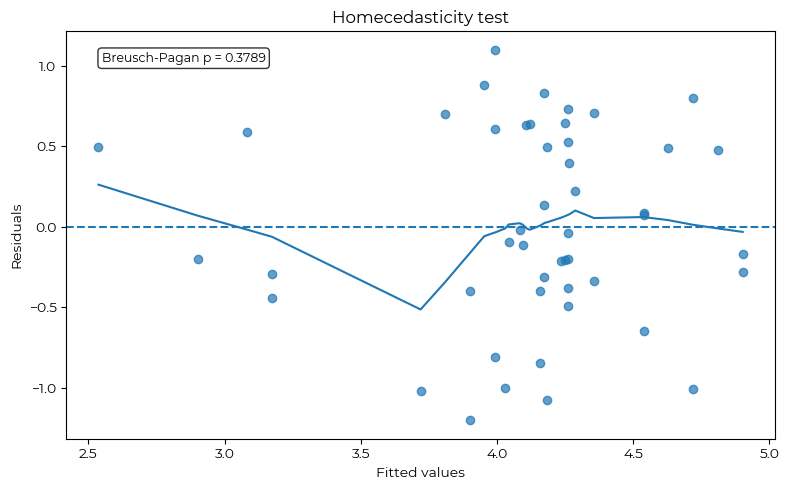

In [ ]:

# Breusch-Pagan test
bp_test = het_breuschpagan(residuals, fitred2.model.exog)
p_value = bp_test[3]  # LM p-value

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(valfit, residuals, alpha=0.7)
smooth = lowess(residuals, valfit, frac=0.6)
ax.plot(smooth[:, 0], smooth[:, 1])
ax.axhline(0, linestyle="--")
ax.set_title(f"Homecedasticity test")

ax.text(
    0.05, 0.95,
    f"Breusch-Pagan p = {p_value:.4f}",
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)
# Etiquetas
ax.set_xlabel("Fitted values")
ax.set_ylabel("Residuals")

plt.tight_layout()
plt.show()

The homoscedasticity test does not reject the null hypothesis, indicating that the variance of the residuals can be considered constant.

#### Normality test

$$H_0 : \varepsilon \backsim N(0, \sigma ^2)~vs~H_a : \varepsilon \nsim N(0, \sigma ^2) $$

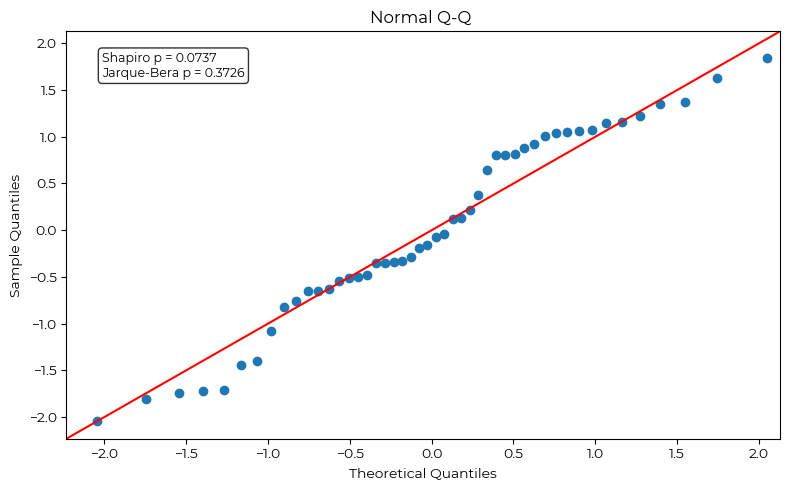

In [ ]:
# Calculate normality tests
shapiro_stat, shapiro_p = shapiro(stud_resid)
jb_stat, jb_p, skew, kurtosis = jarque_bera(stud_resid)

fig, ax = plt.subplots(figsize=(8, 5))

# Q-Q plot
sm.qqplot(stud_resid, line='45', ax=ax)
ax.set_title(
    f"Normal Q-Q "
)

ax.text(
    0.05, 0.95,
    f"Shapiro p = {shapiro_p:.4f}\nJarque-Bera p = {jb_p:.4f}",
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.tight_layout()
plt.show()

For the normality assessment, both the Jarque–Bera and Shapiro–Wilk tests do not reject the null hypothesis, indicating no evidence against the assumption of normality in the residuals.

#### Lineality test


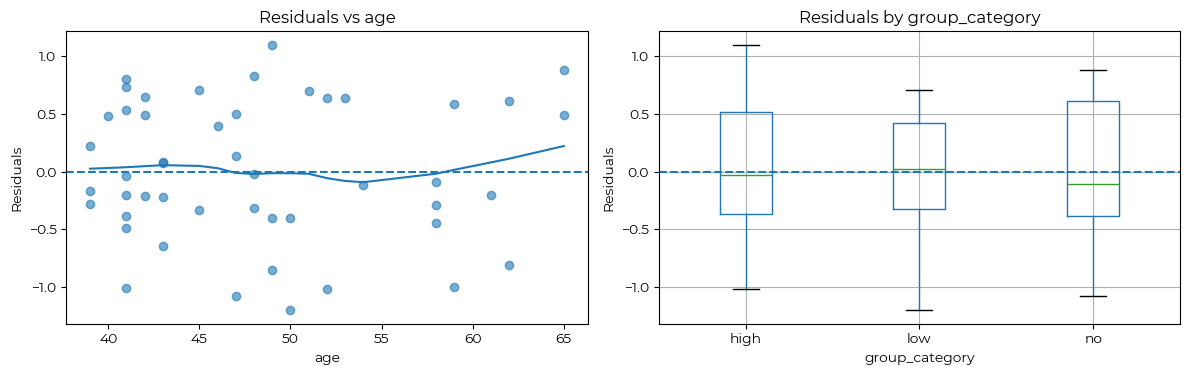

In [20]:
resid = fitred2.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1) Variable numérica: age
x = data_f["age"]

axes[0].scatter(x, resid, alpha=0.6)

smooth = lowess(resid, x, frac=0.6)
axes[0].plot(smooth[:, 0], smooth[:, 1])

axes[0].axhline(0, linestyle="--")
axes[0].set_title("Residuals vs age")
axes[0].set_xlabel("age")
axes[0].set_ylabel("Residuals")


# 2) Variable categórica: group_category
data_plot = data_f.copy()
data_plot["resid"] = resid

data_plot.boxplot(
    column="resid",
    by="group_category",
    ax=axes[1]
)

axes[1].axhline(0, linestyle="--")
axes[1].set_title("Residuals by group_category")
axes[1].set_xlabel("group_category")
axes[1].set_ylabel("Residuals")

# Quitar título automático de pandas
plt.suptitle("")

plt.tight_layout()
plt.show()

Visual inspection suggests no clear deviations from linearity. The relationship between the response and the continuous predictor appears approximately linear, and no systematic patterns are observed in the residuals. Additionally, the distribution of the response across categories shows similar central tendencies, supporting the adequacy of the linear specification.

### Puntual interpretation


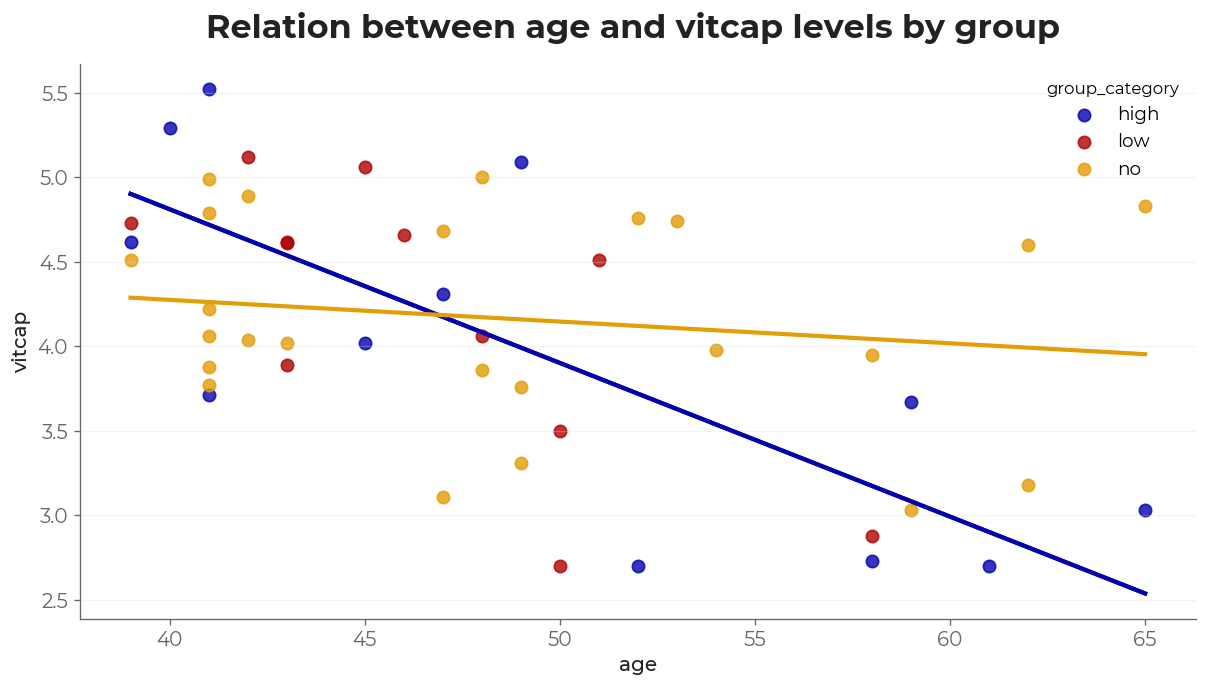

In [21]:
fig, ax = graficar(
    tipo="scatter",
    df=data_f,
    x="age",
    y="vitcap",
    grupo="group_category",
    titulo="Relation between age and vitcap levels by group ",
    estilo=mi_estilo
)

x_vals = np.linspace(data_f["age"].min(), data_f["age"].max(), 100)
color_map = {
    "high": "#0402AB",
    "low": "#0402AB",
    "no": "#E39D06"
}

for group in data_f["group_category"].cat.categories:
    pred_df = pd.DataFrame({
        "age": x_vals,
        "group_category": [group] * len(x_vals)
    })

    y_vals = fitred2.predict(pred_df)

    ax.plot(
        x_vals,
        y_vals,
        linewidth=2.5,
        color=color_map[group],
        label=f"Fitted line: {group}"
    )
plt.show()

The results can be interpreted in multiple ways. One intuitive approach is to focus on a specific age and compare groups at that point. For example, we can analyze what happens for individuals aged 55.

The visualization above provides an initial insight: individuals who are not exposed to cadmium tend to have higher lung capacity compared to those who are exposed.

While this visual interpretation is helpful, it is necessary to formally validate it through a hypothesis test.

Based on model (3), the expected value for each group is:

- For non-exposed individuals:
$$
E(y \mid X) = \beta_0 + \beta_1 \cdot no + \beta_2 \cdot age + \beta_3 \cdot (age \cdot no)
$$

- For exposed individuals:
$$
E(y \mid X) = \beta_0 + \beta_2 \cdot age
$$

Evaluating both expressions at age = 55, we can test whether there is a significant difference between the two groups.

The null hypothesis is:

$$
H_0: \beta_0 + \beta_1 + \beta_2 \cdot 55 + \beta_3 \cdot 55 = \beta_0 + \beta_2 \cdot 55
$$

which simplifies to:

$$
H_0: \beta_1 + \beta_3 \cdot 55 = 0
\quad \text{vs} \quad
H_a: \beta_1 + \beta_3 \cdot 55 \neq 0
$$

In [22]:
# print the names of the variables in the model fitred2
print(fitred2.model.exog_names)


['Intercept', 'I(group_category == "no")[T.True]', 'age', 'I(age * (group_category == "no"))']


In [23]:
# construccion of matrix of contrasts 
K = np.array([
    [0, 1,0, 55] # H0: b2+b3*50 = 0
])

print(fitred2.f_test(K))

<F test: F=6.917832982940724, p=0.011716096426944307, df_denom=44, df_num=1>


Based on the results (p-value = 0.01 < 0.05), we reject the null hypothesis. This provides statistical evidence that, at age 55, individuals who are not exposed to cadmium have higher lung capacity than those who are exposed.

### Confidence Intervals and Interpretation

An alternative way to interpret the model is through a global comparison between groups.

Recall that the reduced model is given by:

$$
\tag{3}
E(y \mid X) = \beta_0 + \beta_1 \cdot no + \beta_2 \cdot age + \beta_3 \cdot (age \cdot no)
$$

Using this formulation, we can evaluate the difference in expected lung capacity between exposed (*high/low*) and non-exposed (*no*) individuals:

$$
E(Y \mid group = exposed, age) - E(Y \mid group = no, age)
$$

Substituting from the model, we obtain:

$$
= [\beta_0 + \beta_2 \cdot age] - [(\beta_0 + \beta_1) + (\beta_2 + \beta_3) \cdot age]
$$

which simplifies to:

$$
= -\beta_1 - \beta_3 \cdot age
$$

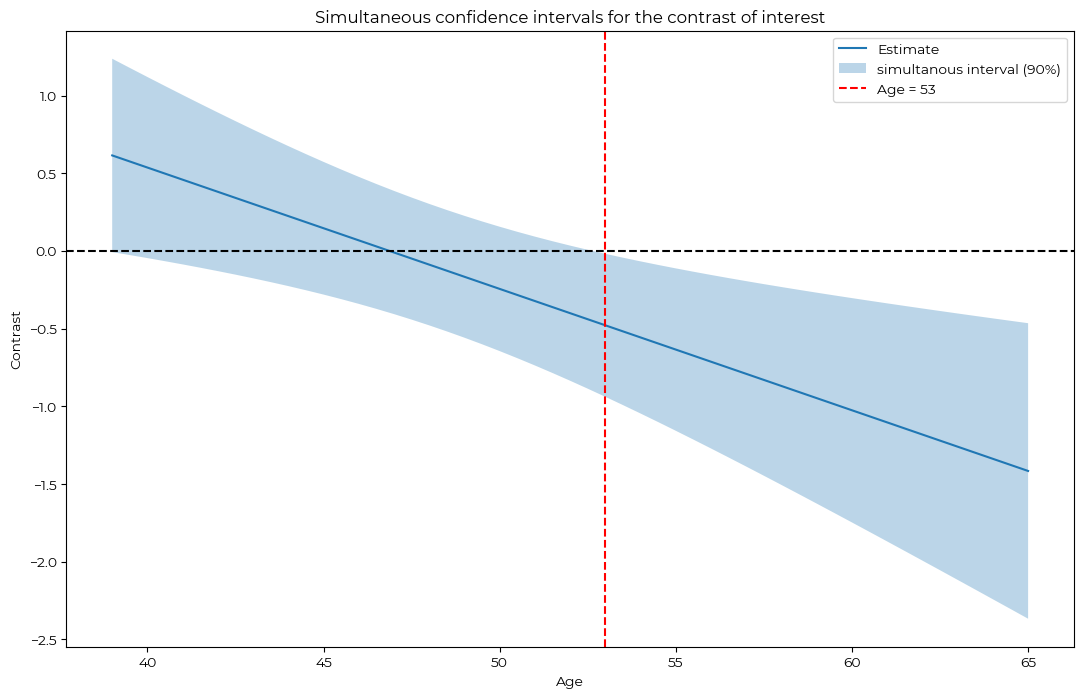

In [30]:

age = np.arange(39, 65.5, 0.5)
len(age)

K = np.column_stack([
    np.zeros(len(age)),   # beta_0
    -np.ones(len(age)),   # beta_1
    np.zeros(len(age)),   # beta_2
    -age                  # beta_3 * age
])

beta_hat = fitred2.params.values
V_beta = fitred2.cov_params().values
df_resid = int(round(fitred2.df_resid))

est = K @ beta_hat

V_lin = K @ V_beta @ K.T
se = np.sqrt(np.diag(V_lin))

t_obs = est / se

Dinv = np.diag(1 / se)
R = Dinv @ V_lin @ Dinv
R = (R + R.T) / 2

sims = rmvt_singular(n_sim=200000, df=df_resid, corr=R, seed=123)
max_abs = np.max(np.abs(sims), axis=1)
c_alpha = np.quantile(max_abs, 0.90)
lower = est - c_alpha * se
upper = est + c_alpha * se

ci = pd.DataFrame({
    "age": age,
    "estimate": est,
    "lower": lower,
    "upper": upper
})
plt.figure( figsize=(13, 8))
plt.plot(age, est, label="Estimate")
plt.fill_between(age, lower, upper, alpha=0.3, label="simultanous interval (90%)")
plt.axhline(0, linestyle="--", color="black")
plt.axvline(53, linestyle="--", color="red", label="Age = 53")
plt.xlabel("Age")
plt.ylabel("Contrast")
plt.legend()
plt.title("Simultaneous confidence intervals for the contrast of interest")
plt.show()

The figure suggests that, for individuals younger than approximately 53 years old, lung capacity tends to be lower among those exposed to cadmium compared to non-exposed individuals.

## Conclusion

In this analysis, we used an ANCOVA framework to study the relationship between lung capacity, age, and cadmium exposure.

The initial model allowed for different slopes across groups, and hypothesis testing revealed that the assumption of parallel lines was not fully supported. However, further analysis showed that the *high* and *low* exposure groups exhibited similar behavior, which justified combining them into a single "exposed" category.

This simplification led to a more interpretable model, while preserving the key differences between exposed and non-exposed individuals.

Model diagnostics indicated that the main regression assumptions—linearity, homoscedasticity, and normality of residuals—were reasonably satisfied, supporting the validity of the inference.

From an interpretative perspective, the results show that the effect of cadmium exposure is not constant, but depends on age. In particular, both the analytical results and visualizations suggest that, for individuals younger than approximately 53 years old, exposure is associated with lower lung capacity.

Additionally, hypothesis testing at a specific age (e.g., 55 years) confirmed that the difference between exposed and non-exposed individuals is statistically significant.

Overall, this analysis highlights the importance of:
- adjusting for continuous variables when comparing groups,
- carefully evaluating interaction effects, and  
- balancing model complexity and interpretability.

This case study illustrates how statistical modeling can provide meaningful insights beyond simple group comparisons, especially when the relationship between variables is not constant across the population.